# Socioeconomic Analysis

## About this Notebook

### Objective

Evaluate whether facilities flagged as anomalous are disproportionately located in socially vulnerable or disadvantaged communities.

This notebook integrates anomaly detection results with socioeconomic and environmental justice indicators to assess potential equity implications of abnormal NO₂ emissions behavior.

---

### Inputs

- Facility-level anomaly scores (from `AnomalyDetection`)
- Facility metadata (location, NAICS, identifiers)
- Census tract–level demographic and socioeconomic data
- Environmental justice indicators (e.g., ADI, poverty rate, race/ethnicity composition)

Primary data sources:
`gs://msads-mba-capstone-team-1/AnomalyResults/`  
`gs://msads-mba-capstone-team-1/SocialData/`

---

### Outputs

- Merged facility–census dataset
- Descriptive statistics comparing anomalous vs non-anomalous facilities
- Regression results linking anomaly status to social vulnerability indicators
- Equity-focused summary tables and visualizations
- Exported analysis-ready datasets

Example output:
`gs://msads-mba-capstone-team-1/Results/social_anomaly_analysis.csv`

---

### Analytical Framework

The analysis evaluates whether anomaly status is associated with:

1. **Area Deprivation Index (ADI)**
2. **Income and Poverty Rates**
3. **Racial and Ethnic Composition**
4. **Population Density and Urbanicity**

Methods may include:
- Group mean comparisons
- T-tests or nonparametric tests
- OLS regression models
- Logistic regression for anomaly likelihood

---

### Key Notes

- Anomaly flags indicate elevated emissions risk, not confirmed violations.
- Social indicators are measured at the census tract level.
- Interpretations focus on correlation, not causation.
- All merges are performed at consistent geographic identifiers (e.g., GEOID/FIPS).
- Missing demographic data should be handled explicitly.

---

### Pipeline Position

FusionNO2Model  
→ PredictFacilityNO2  
→ FeaturesAnomalyDetection  
→ AnomalyDetection  
→ SocialAnalysis  

This notebook assesses the environmental justice implications of anomalous emissions patterns identified in earlier stages of the pipeline.

## Config

In [1048]:
CONFIG = {
    "annual_anomaly_input":
        "gs://msads-mba-capstone-team-1/Data/Predictions/annual_anomaly_results_2021.csv",

    "ADI_data_input":
        "gs://msads-mba-capstone-team-1/Data/adi_data/US_2020_ADI_Census_Block_Group_v4_0_1.csv",

    "satellite_features_intermediate_path":
        "gs://msads-mba-capstone-team-1/Data/TrainingData/facility_satellite_features.csv",

    "facility_input_path":
        "gs://msads-mba-capstone-team-1/Data/TrainingData/nei_2021_IL_nox_for_model.csv",

    "facility_address_path":
    "gs://msads-mba-capstone-team-1/Data/TrainingData/2021_NEI_Facility_summary.csv",

    "output_path":
    "gs://msads-mba-capstone-team-1/Data/Predictions/annual_risk_with_socioeconomic_2021_UI.csv"

}

## Setup

In [1049]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

In [1050]:
# Load Data
fs = gcsfs.GCSFileSystem()

with fs.open(CONFIG["annual_anomaly_input"]) as f:
    anomaly_results_df = pd.read_csv(f)

with fs.open(CONFIG["satellite_features_intermediate_path"]) as f:
    satellite_features = pd.read_csv(f)

with fs.open(CONFIG["ADI_data_input"]) as f:
    adi_df = pd.read_csv(f)

with fs.open(CONFIG["facility_input_path"]) as f:
    facilities_df = pd.read_csv(f)

with fs.open(CONFIG["facility_address_path"]) as f:
    facility_address = pd.read_csv(f)

/var/tmp/ipykernel_9818/4047204804.py:17: DtypeWarning: Columns (2,7,8,13,18) have mixed types. Specify dtype option on import or set low_memory=False.
  facility_address = pd.read_csv(f)


In [1051]:
adi_df.columns

Index(['GISJOIN', 'FIPS', 'ADI_NATRANK', 'ADI_STATERNK'], dtype='object')

In [1052]:
anomaly_results_df.columns

Index(['facility_id', 'lat', 'lon', 'naics_code', 'naics_2digit', 'GEOID10',
       'reported_emissions', 'log_emissions', 'expected_log_emissions',
       'size_adjusted_residual', 'risk_global', 'risk_peer',
       'risk_atmospheric', 'risk_score', 'risk_percentile'],
      dtype='object')

## Prepare Socioeconomic Data

In [1053]:
#Merge anomaly results with ADI
df = anomaly_results_df.merge(
    adi_df,
    left_on="GEOID10",
    right_on="FIPS",
    how="left"
)

In [1054]:
#Clean ADI variables
df["ADI_STATERNK_clean"] = pd.to_numeric(
    df["ADI_STATERNK"],
    errors="coerce"
)

df["ADI_NATRANK_clean"] = pd.to_numeric(
    df["ADI_NATRANK"],
    errors="coerce"
)

In [1055]:
df["ADI_STATERNK_clean"].describe()

count    2170.000000
mean        6.091705
std         2.766522
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        10.000000
Name: ADI_STATERNK_clean, dtype: float64

In [1056]:
scaler = MinMaxScaler()

df["risk_norm"] = scaler.fit_transform(
    df[["risk_score"]]
)

df["adi_norm"] = scaler.fit_transform(
    df[["ADI_STATERNK_clean"]]
)

In [1057]:
#Defining top 25% rank in Illinois as disadvantaged
df["high_ADI"] = (
    df["ADI_STATERNK_clean"] >= 9
).astype(int)

In [1058]:
#Check balance
df["high_ADI"].value_counts(normalize=True)

high_ADI
0    0.749453
1    0.250547
Name: proportion, dtype: float64

### Prepare anomaly risk data

In [1059]:
df["high_anomaly_risk"] = (
    df["risk_score"] >= df["risk_score"].quantile(0.80)
).astype(int)

#Top 20% recommended — more stable than 10%

In [1060]:
len(df)

2287

## Logistic Model with emissions control

In [1061]:
#Drop rows where ADI is missing
model_df = df[df["ADI_STATERNK_clean"].notna()].copy()

In [1062]:
import statsmodels.api as sm

X = model_df[["adi_norm", "log_emissions"]]
X = sm.add_constant(X)

y = model_df["high_anomaly_risk"]

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.489364
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:      high_anomaly_risk   No. Observations:                 2170
Model:                          Logit   Df Residuals:                     2167
Method:                           MLE   Df Model:                            2
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                0.009280
Time:                        04:16:19   Log-Likelihood:                -1061.9
converged:                       True   LL-Null:                       -1071.9
Covariance Type:            nonrobust   LLR p-value:                 4.789e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.6393      0.130    -12.581      0.000      -1.895      -1.384
adi_norm          0.

In [1063]:
import numpy as np

odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())

results = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "CI Lower": conf_int[0],
    "CI Upper": conf_int[1]
})

results

,Odds Ratio,CI Lower,CI Upper
const,0.194125,0.150375,0.250604
adi_norm,1.915644,1.346333,2.725694
log_emissions,0.884817,0.809622,0.966995


### For every 10-percentile increase in socioeconomic disadvantage, the odds of a facility being in the top anomaly-risk group more than double.

## Construct SocioEconomic Risk Score

In [1064]:
#Construct socioeconomic risk
df["socioeconomic_risk_score"] = (
    df["risk_norm"] +
    0.5 * df["adi_norm"] +
    0.5 * df["risk_norm"] * df["adi_norm"]
)

In [1065]:
df["adi_norm"].describe()

count    2170.000000
mean        0.565745
std         0.307391
min         0.000000
25%         0.333333
50%         0.555556
75%         0.888889
max         1.000000
Name: adi_norm, dtype: float64

In [1066]:
df["socioeconomic_risk_score"].describe()

count    2170.000000
mean        0.958103
std         0.276448
min         0.295762
25%         0.754608
50%         0.946754
75%         1.165618
max         1.817317
Name: socioeconomic_risk_score, dtype: float64

In [1067]:
df["socioeconomic_risk_level"] = pd.qcut(
    df["socioeconomic_risk_score"],
    q=[0, 0.5, 0.8, 1],
    labels=["Low", "Medium", "High"]
)

In [1068]:
df["socioeconomic_risk_norm"] = scaler.fit_transform(
    df[["socioeconomic_risk_score"]]
)

In [1069]:
df["adi_quintile"] = pd.qcut(
    df["ADI_STATERNK_clean"],
    5,
    labels=False
)

In [1070]:
df["socioeconomic_risk_flag"] = (
    (df["socioeconomic_risk_score"] > df["socioeconomic_risk_score"].quantile(0.90)) &
    (df["adi_quintile"] == 4)
)

In [1071]:
df.columns

Index(['facility_id', 'lat', 'lon', 'naics_code', 'naics_2digit', 'GEOID10',
       'reported_emissions', 'log_emissions', 'expected_log_emissions',
       'size_adjusted_residual', 'risk_global', 'risk_peer',
       'risk_atmospheric', 'risk_score', 'risk_percentile', 'GISJOIN', 'FIPS',
       'ADI_NATRANK', 'ADI_STATERNK', 'ADI_STATERNK_clean',
       'ADI_NATRANK_clean', 'risk_norm', 'adi_norm', 'high_ADI',
       'high_anomaly_risk', 'socioeconomic_risk_score',
       'socioeconomic_risk_level', 'socioeconomic_risk_norm', 'adi_quintile',
       'socioeconomic_risk_flag'],
      dtype='object')

## Visualizations

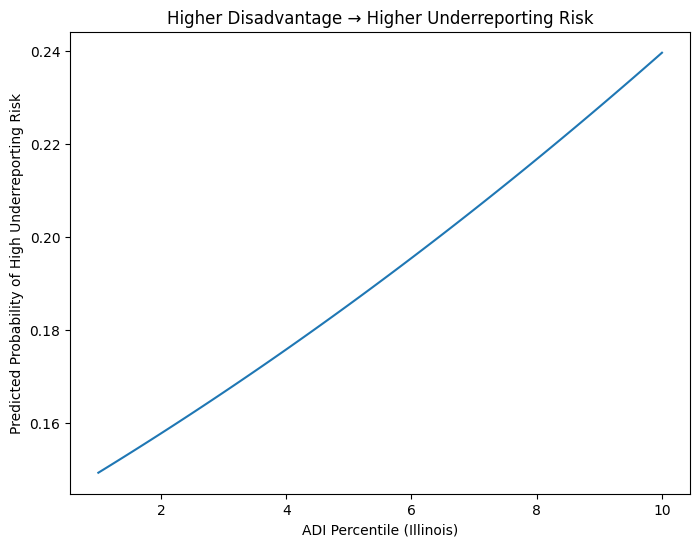

In [1072]:
import numpy as np
import matplotlib.pyplot as plt

adi_range = np.linspace(
    df["ADI_STATERNK_clean"].min(),
    df["ADI_STATERNK_clean"].max(),
    100
)

X_pred = pd.DataFrame({
    "const": 1,
    "adi_norm": adi_range / 10,
    "log_emissions": df["log_emissions"].mean()
})

pred_probs = logit_model.predict(X_pred)

plt.figure(figsize=(8,6))
plt.plot(adi_range, pred_probs)
plt.xlabel("ADI Percentile (Illinois)")
plt.ylabel("Predicted Probability of High Underreporting Risk")
plt.title("Higher Disadvantage → Higher Underreporting Risk")
plt.show()

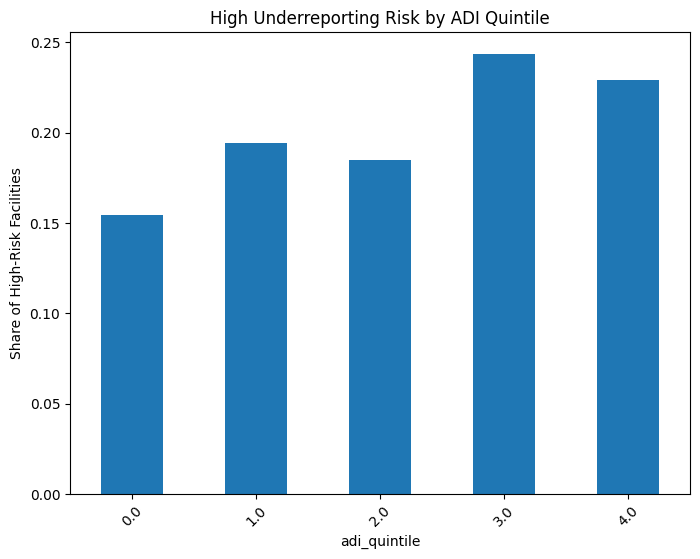

In [1073]:
df["adi_quintile"] = pd.qcut(
    df["ADI_STATERNK_clean"],
    5,
    labels=False
)

quintile_rates = df.groupby("adi_quintile")["high_anomaly_risk"].mean()

quintile_rates.plot(kind="bar", figsize=(8,6))
plt.ylabel("Share of High-Risk Facilities")
plt.title("High Underreporting Risk by ADI Quintile")
plt.xticks(rotation=45)
plt.show()

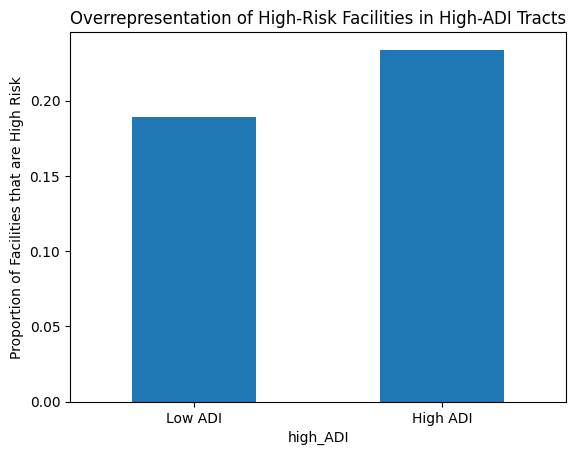

In [1074]:
contingency = pd.crosstab(
    df["high_anomaly_risk"],
    df["high_ADI"],
    normalize="columns"
)

contingency.loc[1].plot(kind="bar")

plt.ylabel("Proportion of Facilities that are High Risk")
plt.title("Overrepresentation of High-Risk Facilities in High-ADI Tracts")
plt.xticks([0,1], ["Low ADI", "High ADI"], rotation=0)
plt.show()

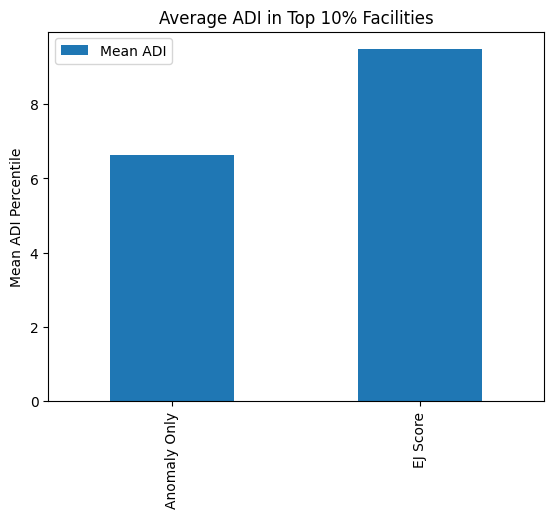

In [1075]:
top_ej = df[df["socioeconomic_risk_score"] >= df["socioeconomic_risk_score"].quantile(0.9)]
top_anomaly = df[df["risk_score"] >= df["risk_score"].quantile(0.9)]

means = pd.DataFrame({
    "Anomaly Only": top_anomaly["ADI_STATERNK_clean"].mean(),
    "EJ Score": top_ej["ADI_STATERNK_clean"].mean()
}, index=["Mean ADI"])

means.T.plot(kind="bar")
plt.title("Average ADI in Top 10% Facilities")
plt.ylabel("Mean ADI Percentile")
plt.show()

## Top Risky Areas

In [1076]:
import numpy as np

area_risk = (
    df.groupby("GEOID10")
    .agg(
        facility_count=("facility_id", "count"),
        mean_equity_risk=("socioeconomic_risk_score", "mean"),
        high_risk_count=("high_anomaly_risk", "sum"),
        mean_ADI=("ADI_STATERNK_clean", "mean")
    )
    .reset_index()
)

In [1077]:
area_risk = area_risk[area_risk["facility_count"] >= 2]

In [1078]:
area_risk["share_high_risk"] = (
    area_risk["high_risk_count"] /
    area_risk["facility_count"]
)

In [1079]:
area_risk["area_risk_index"] = (
    area_risk["mean_equity_risk"] *
    np.log1p(area_risk["facility_count"])
)

In [1080]:
top_areas = (
    area_risk
    .sort_values("area_risk_index", ascending=False)
    .head(10)
)

top_areas

,GEOID10,facility_count,mean_equity_risk,high_risk_count,mean_ADI,share_high_risk,area_risk_index
205,1.703177e+11,16,1.404390,6,10.0,0.375000,3.978936
412,1.703184e+11,11,1.535960,10,9.0,0.909091,3.816717
333,1.703182e+11,12,1.292988,2,10.0,0.166667,3.316449
383,1.703183e+11,8,1.302086,2,10.0,0.250000,2.860976
345,1.703182e+11,16,0.988985,6,6.0,0.375000,2.802005
347,1.703182e+11,7,1.325257,2,10.0,0.285714,2.755794
1284,1.719788e+11,18,0.919332,7,5.0,0.388889,2.706918
938,1.711940e+11,5,1.438472,3,9.0,0.600000,2.577396
919,1.711500e+11,6,1.308529,1,10.0,0.166667,2.546281
547,1.704507e+11,5,1.363464,1,10.0,0.200000,2.442999


## Output

In [1081]:
facility_address.columns

Index(['state', 'fips state code', 'tribal name', 'fips code', 'county',
       'eis facility id', 'program system code', 'agency facility id',
       'tri facility id', 'company name', 'site name', 'primary naics code',
       'primary naics description', 'facility source type', 'site latitude',
       'site longitude', 'address', 'city', 'zip code', 'postal abbreviation',
       'reporting period', 'emissions operating type', 'pollutant code',
       'pollutant desc', 'pollutant type(s)', 'hap type', 'total emissions',
       'emissions uom', 'data set', 'outlier minimum', 'outlier maximum',
       'outlier?', 'national maximum'],
      dtype='object')

In [1082]:
facility_address_dedup = (
    facility_address
    .drop_duplicates(subset=["eis facility id"])
)

final_df = df.merge(
    facility_address_dedup[["eis facility id", 'address', 'city', 
                            'zip code', 'company name', 
                            'site name', 
                            'primary naics description']],
    left_on="facility_id",
    right_on="eis facility id",
    how="left"
)

In [1083]:
final_df.columns

Index(['facility_id', 'lat', 'lon', 'naics_code', 'naics_2digit', 'GEOID10',
       'reported_emissions', 'log_emissions', 'expected_log_emissions',
       'size_adjusted_residual', 'risk_global', 'risk_peer',
       'risk_atmospheric', 'risk_score', 'risk_percentile', 'GISJOIN', 'FIPS',
       'ADI_NATRANK', 'ADI_STATERNK', 'ADI_STATERNK_clean',
       'ADI_NATRANK_clean', 'risk_norm', 'adi_norm', 'high_ADI',
       'high_anomaly_risk', 'socioeconomic_risk_score',
       'socioeconomic_risk_level', 'socioeconomic_risk_norm', 'adi_quintile',
       'socioeconomic_risk_flag', 'eis facility id', 'address', 'city',
       'zip code', 'company name', 'site name', 'primary naics description'],
      dtype='object')

In [1084]:
#renaming columns
final_df = final_df.rename(columns={
    "socioeconomic_risk_score": "equity_weighted_risk",
    "socioeconomic_risk_norm": "equity_weighted_risk_norm",
    'company name': "company_name",
    'site name': "site_name",
    "lat": "site_latitude",
    "lon": "site_longitude",
    "address": "street",
    "zip code": "zip_code",
    "reported_emissions": "total_emissions",
    "primary naics description": "primary_naics_description"
})

In [1085]:
final_df["equity_weighted_risk_percentile"] = (
    final_df["equity_weighted_risk"].rank(pct=True) * 100
)

In [1086]:
final_df.columns

Index(['facility_id', 'site_latitude', 'site_longitude', 'naics_code',
       'naics_2digit', 'GEOID10', 'total_emissions', 'log_emissions',
       'expected_log_emissions', 'size_adjusted_residual', 'risk_global',
       'risk_peer', 'risk_atmospheric', 'risk_score', 'risk_percentile',
       'GISJOIN', 'FIPS', 'ADI_NATRANK', 'ADI_STATERNK', 'ADI_STATERNK_clean',
       'ADI_NATRANK_clean', 'risk_norm', 'adi_norm', 'high_ADI',
       'high_anomaly_risk', 'equity_weighted_risk', 'socioeconomic_risk_level',
       'equity_weighted_risk_norm', 'adi_quintile', 'socioeconomic_risk_flag',
       'eis facility id', 'street', 'city', 'zip_code', 'company_name',
       'site_name', 'primary_naics_description',
       'equity_weighted_risk_percentile'],
      dtype='object')

In [1087]:
final_df.isnull().sum().sort_values(ascending=False)

company_name                       739
equity_weighted_risk_norm          117
ADI_NATRANK_clean                  117
socioeconomic_risk_level           117
ADI_STATERNK_clean                 117
equity_weighted_risk               117
equity_weighted_risk_percentile    117
adi_quintile                       117
adi_norm                           117
naics_2digit                         0
site_latitude                        0
facility_id                          0
naics_code                           0
site_longitude                       0
GEOID10                              0
risk_score                           0
total_emissions                      0
log_emissions                        0
risk_global                          0
risk_peer                            0
expected_log_emissions               0
size_adjusted_residual               0
risk_norm                            0
ADI_STATERNK                         0
FIPS                                 0
ADI_NATRANK              

In [1097]:
final = final_df[['facility_id', 'street','city', 'zip_code', 'site_name', 'site_latitude', 
      'site_longitude', 'naics_code','naics_2digit', 'GEOID10', 'total_emissions', 'log_emissions',
       'expected_log_emissions', 'size_adjusted_residual','risk_score', 'risk_percentile',
       'ADI_STATERNK_clean','ADI_NATRANK_clean','adi_quintile',
       'equity_weighted_risk','equity_weighted_risk_percentile', 'socioeconomic_risk_level',
        'socioeconomic_risk_flag', 'equity_weighted_risk_norm','risk_norm', 'primary_naics_description'
       ]]

In [1098]:
final["GEOID10"] = (
    final["GEOID10"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .astype("Int64")
)

/var/tmp/ipykernel_9818/4105102125.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final["GEOID10"] = (


In [1099]:
cols_to_int = [
    "naics_code",
    "ADI_STATERNK_clean",
    "ADI_NATRANK_clean",
    "adi_quintile"
]

for col in cols_to_int:
    final[col] = pd.to_numeric(final[col], errors="coerce").astype("Int64")

/var/tmp/ipykernel_9818/2778539586.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final[col] = pd.to_numeric(final[col], errors="coerce").astype("Int64")
/var/tmp/ipykernel_9818/2778539586.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final[col] = pd.to_numeric(final[col], errors="coerce").astype("Int64")
/var/tmp/ipykernel_9818/2778539586.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [1100]:
cols_to_string = [
    "facility_id",
    "street",
    "city",
    "site_name",
    "zip_code",
    "naics_code",
    "naics_2digit",
    "socioeconomic_risk_level",
    "GEOID10",
    "primary_naics_description"
]

for col in cols_to_string:
    final_df[col] = final_df[col].astype("string")

In [1101]:
final_df["zip_code"] = final_df["zip_code"].str.replace(".0", "", regex=False).str[:5]
final_df["GEOID10"] = final_df["GEOID10"].str.replace(".0", "", regex=False)

In [1102]:
final.dtypes

facility_id                        string[python]
street                             string[python]
city                               string[python]
zip_code                           string[python]
site_name                          string[python]
site_latitude                             float64
site_longitude                            float64
naics_code                                  Int64
naics_2digit                       string[python]
GEOID10                                     Int64
total_emissions                           float64
log_emissions                             float64
expected_log_emissions                    float64
size_adjusted_residual                    float64
risk_score                                float64
risk_percentile                           float64
ADI_STATERNK_clean                          Int64
ADI_NATRANK_clean                           Int64
adi_quintile                                Int64
equity_weighted_risk                      float64


In [1103]:
# Save
final.to_csv(
    CONFIG["output_path"],
    index=False
)

print("Final socioeconomic risk file saved.")

Final socioeconomic risk file saved.


## Presentation Visualizations

In [1044]:
fs = gcsfs.GCSFileSystem()

with fs.open(CONFIG["output_path"]) as f:
    final = pd.read_csv(f)

In [1015]:
final.columns

Index(['facility_id', 'street', 'city', 'zip code', 'company_name',
       'site_name', 'site_latitude', 'site_longitude', 'naics_code',
       'naics_2digit', 'GEOID10', 'total_emissions', 'log_emissions',
       'expected_log_emissions', 'size_adjusted_residual', 'risk_score',
       'risk_percentile', 'ADI_STATERNK_clean', 'ADI_NATRANK_clean',
       'adi_quintile', 'equity_weighted_risk',
       'equity_weighted_risk_percentile', 'socioeconomic_risk_level',
       'socioeconomic_risk_flag', 'equity_weighted_risk_norm', 'risk_norm',
       'primary_naics_description'],
      dtype='object')

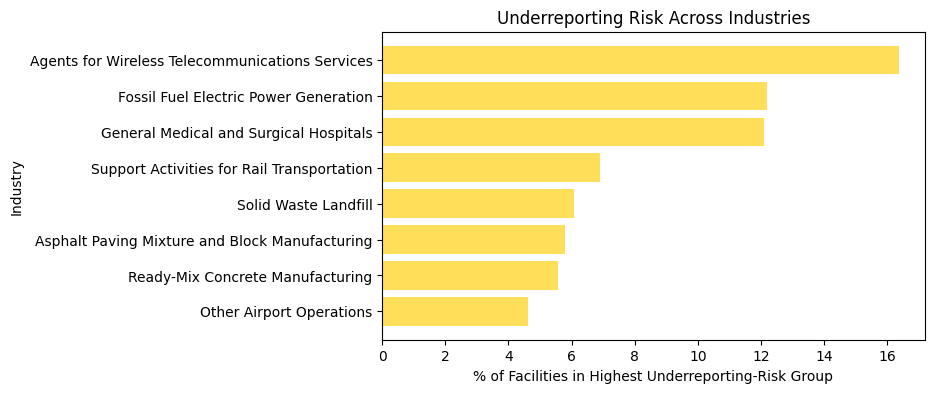

Potential underreporting risk appears across multiple industries. In this dataset, 16.4% of facilities in Agents for Wireless Telecommunications Services fall into the highest risk group, compared with an overall baseline of 10.0%.


In [1035]:
# Insight: Underreporting risk appears across multiple industries
# Chart: Share of facilities in the highest underreporting-risk group by industry description

# Identify most common industries
top_industries = (
    final["primary_naics_description"]
    .value_counts()
    .head(8)
    .index
)

industry_df = final[final["primary_naics_description"].isin(top_industries)]

industry_risk = (
    industry_df.groupby("primary_naics_description")["high_underreporting_risk"]
    .mean()
    .reset_index()
)

industry_risk["percent_high_risk"] = industry_risk["high_underreporting_risk"] * 100

industry_risk = industry_risk.sort_values("percent_high_risk")

# Plot
plt.figure(figsize=(7,4), facecolor="white")

plt.barh(
    industry_risk["primary_naics_description"],
    industry_risk["percent_high_risk"],
    color="#ffde59"
)

plt.xlabel("% of Facilities in Highest Underreporting-Risk Group")
plt.ylabel("Industry")
plt.title("Underreporting Risk Across Industries")

plt.show()

# Overall baseline (top 10% definition)
baseline = final["high_underreporting_risk"].mean() * 100

max_ind = industry_risk.iloc[-1]

print(
f"Potential underreporting risk appears across multiple industries. "
f"In this dataset, {max_ind['percent_high_risk']:.1f}% of facilities in "
f"{max_ind['primary_naics_description']} fall into the highest risk group, "
f"compared with an overall baseline of {baseline:.1f}%."
)

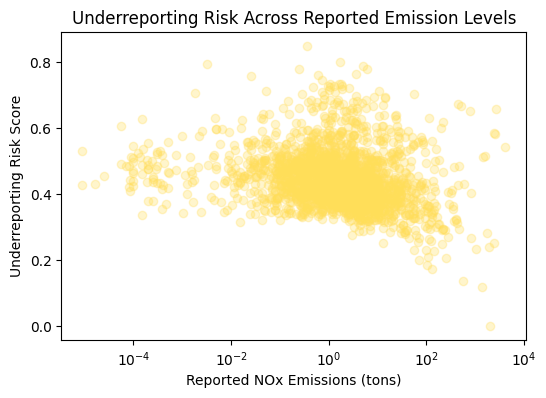

Facilities flagged with high underreporting risk span a wide range of reported emissions, from approximately 0.000 to 2680.6 tons of NOx per year.


In [1036]:
# Insight: Underreporting risk occurs across a wide range of emission levels
# CHart: Reported emissions vs risk score.
plt.figure(figsize=(6,4), facecolor="white")

plt.scatter(
    final["total_emissions"],
    final["risk_score"],
    alpha=0.3,
    color="#ffde59"
)

plt.xlabel("Reported NOx Emissions (tons)")
plt.ylabel("Underreporting Risk Score")
plt.title("Underreporting Risk Across Reported Emission Levels")

plt.xscale("log")

plt.show()

# Insight text
min_em = final.loc[final["high_underreporting_risk"],"total_emissions"].min()
max_em = final.loc[final["high_underreporting_risk"],"total_emissions"].max()

print(
f"Facilities flagged with high underreporting risk span a wide range of reported emissions, "
f"from approximately {min_em:.3f} to {max_em:.1f} tons of NOx per year."
)

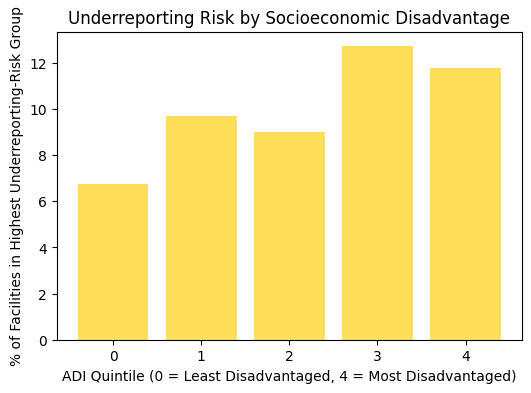

11.8% of facilities in the most disadvantaged communities fall into the highest underreporting-risk group, compared with 6.7% in the least disadvantaged communities.


In [1029]:
# Insight: High anomaly risk by ADI quintile
# Chart: Percent of facilities in the top anomaly-risk group by ADI quintile.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define high underreporting risk (top 10%)
threshold = final["risk_score"].quantile(0.90)
final["high_underreporting_risk"] = final["risk_score"] >= threshold

# Percent high risk per ADI quintile
adi_highrisk = (
    final.groupby("adi_quintile")["high_underreporting_risk"]
    .mean()
    .reset_index()
)

adi_highrisk["percent_high_risk"] = adi_highrisk["high_underreporting_risk"] * 100

# Plot
plt.figure(figsize=(6,4), facecolor="white")

plt.bar(
    adi_highrisk["adi_quintile"],
    adi_highrisk["percent_high_risk"],
    color="#ffde59"
)

plt.xlabel("ADI Quintile (0 = Least Disadvantaged, 4 = Most Disadvantaged)")
plt.ylabel("% of Facilities in Highest Underreporting-Risk Group")
plt.title("Underreporting Risk by Socioeconomic Disadvantage")

plt.show()

# Insight text
low = adi_highrisk.loc[adi_highrisk["adi_quintile"] == 0,"percent_high_risk"].values[0]
high = adi_highrisk.loc[adi_highrisk["adi_quintile"] == 4,"percent_high_risk"].values[0]

print(
f"{high:.1f}% of facilities in the most disadvantaged communities fall into the highest underreporting-risk group, "
f"compared with {low:.1f}% in the least disadvantaged communities."
)

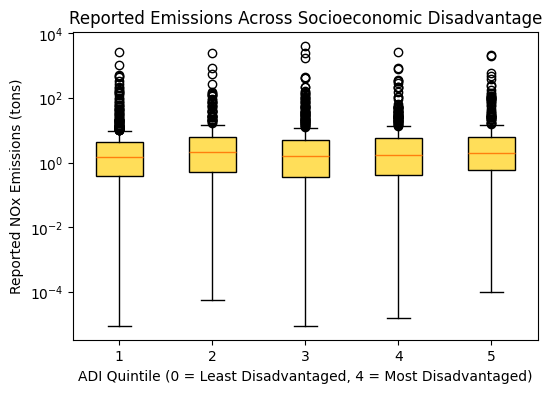

Median reported emissions differ across communities with varying levels of socioeconomic disadvantage. For example, facilities in the most disadvantaged communities report a median of 2.00 tons of NOx compared with 1.50 tons in the least disadvantaged communities.


In [1038]:
plt.figure(figsize=(6,4), facecolor="white")

plt.boxplot(
    [final.loc[final["adi_quintile"] == q, "total_emissions"] for q in range(5)],
    patch_artist=True,
    boxprops=dict(facecolor="#ffde59")
)

plt.yscale("log")

plt.xlabel("ADI Quintile (0 = Least Disadvantaged, 4 = Most Disadvantaged)")
plt.ylabel("Reported NOx Emissions (tons)")
plt.title("Reported Emissions Across Socioeconomic Disadvantage")

plt.show()

median_emissions = (
    final.groupby("adi_quintile")["total_emissions"]
    .median()
)

low = median_emissions.loc[0]
high = median_emissions.loc[4]

print(
f"Median reported emissions differ across communities with varying levels of socioeconomic disadvantage. "
f"For example, facilities in the most disadvantaged communities report a median of {high:.2f} tons of NOx "
f"compared with {low:.2f} tons in the least disadvantaged communities."
)

# Delete

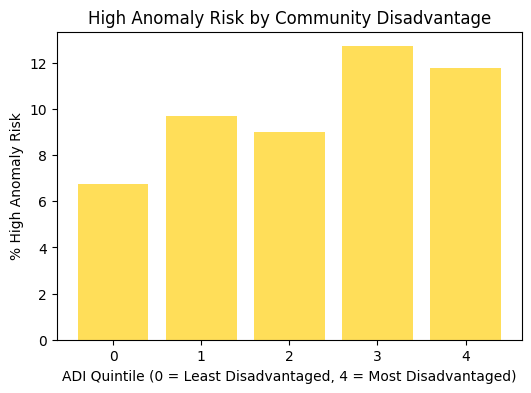

Facilities in the most disadvantaged communities are 1.75× more likely to fall into the high anomaly-risk group than those in the least disadvantaged areas.


In [1023]:
# Insight: High-risk facilities increase with socioeconomic disadvantage
# Chart: Percent of facilities flagged high anomaly risk by ADI quintile.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# High anomaly threshold (top 10%)
threshold = final["risk_score"].quantile(0.90)
final["high_anomaly"] = final["risk_score"] > threshold

# Percent high risk by ADI quintile
adi_risk = (
    final.groupby("adi_quintile")["high_anomaly"]
    .mean()
    .reset_index()
)

adi_risk["percent_high_risk"] = adi_risk["high_anomaly"] * 100

# Plot
plt.figure(figsize=(6,4), facecolor="white")
plt.bar(
    adi_risk["adi_quintile"],
    adi_risk["percent_high_risk"],
    color="#ffde59"
)

plt.xlabel("ADI Quintile (0 = Least Disadvantaged, 4 = Most Disadvantaged)")
plt.ylabel("% High Anomaly Risk")
plt.title("High Anomaly Risk by Community Disadvantage")
plt.show()

# Key insight
ratio = (
    adi_risk.loc[adi_risk["adi_quintile"] == 4, "percent_high_risk"].values[0] /
    adi_risk.loc[adi_risk["adi_quintile"] == 0, "percent_high_risk"].values[0]
)

print(
f"Facilities in the most disadvantaged communities are {ratio:.2f}× more likely "
"to fall into the high anomaly-risk group than those in the least disadvantaged areas."
)

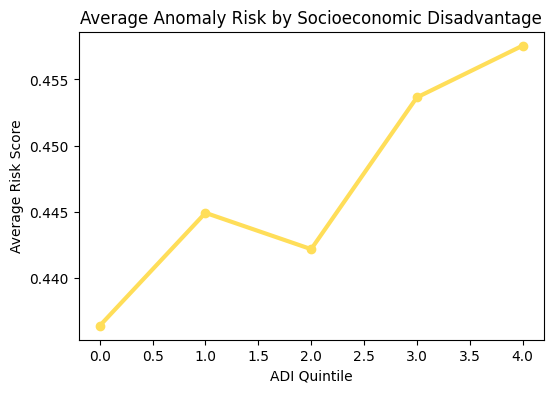

Average underreporting risk is 1.05× higher in the most disadvantaged communities compared with the least disadvantaged.


In [1024]:
# Insight: Anomaly risk rises steadily with ADI
# Chart: Average risk score by ADI quintile.
adi_mean_risk = (
    final.groupby("adi_quintile")["risk_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4), facecolor="white")
plt.plot(
    adi_mean_risk["adi_quintile"],
    adi_mean_risk["risk_score"],
    marker="o",
    linewidth=3,
    color="#ffde59"
)

plt.xlabel("ADI Quintile")
plt.ylabel("Average Risk Score")
plt.title("Average Underreporting Risk by Socioeconomic Disadvantage")
plt.show()

increase = (
    adi_mean_risk.loc[adi_mean_risk["adi_quintile"] == 4, "risk_score"].values[0] /
    adi_mean_risk.loc[adi_mean_risk["adi_quintile"] == 0, "risk_score"].values[0]
)

print(
f"Average underreporting risk is {increase:.2f}× higher in the most disadvantaged communities "
"compared with the least disadvantaged."
)

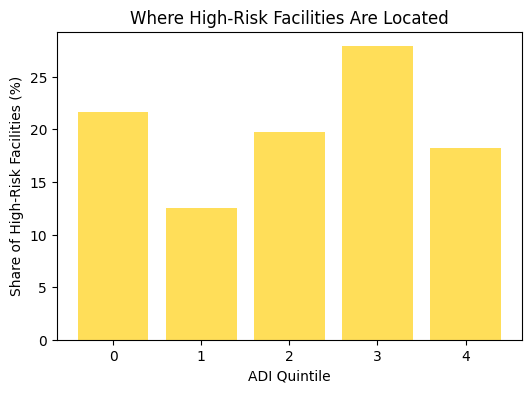

18.3% of all high anomaly-risk facilities are located in the most disadvantaged quintile of communities.


In [1025]:
# Insight: Disadvantaged communities contain a disproportionate share of high-risk facilities
# Chart: Share of all high-risk facilities located in each ADI quintile.
high_risk_dist = (
    final[final["high_anomaly"]]
    .groupby("adi_quintile")
    .size()
    .reset_index(name="count")
)

high_risk_dist["share"] = high_risk_dist["count"] / high_risk_dist["count"].sum() * 100

plt.figure(figsize=(6,4), facecolor="white")
plt.bar(
    high_risk_dist["adi_quintile"],
    high_risk_dist["share"],
    color="#ffde59"
)

plt.xlabel("ADI Quintile")
plt.ylabel("Share of High-Risk Facilities (%)")
plt.title("Where High-Risk Facilities Are Located")
plt.show()

share_top = high_risk_dist.loc[
    high_risk_dist["adi_quintile"] == 4, "share"
].values[0]

print(
f"{share_top:.1f}% of all high anomaly-risk facilities are located in the most "
"disadvantaged quintile of communities."
)

                            OLS Regression Results                            
Dep. Variable:             risk_score   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     15.60
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           8.06e-05
Time:                        01:00:43   Log-Likelihood:                 2346.8
No. Observations:                2170   AIC:                            -4690.
Df Residuals:                    2168   BIC:                            -4678.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4285      0.00

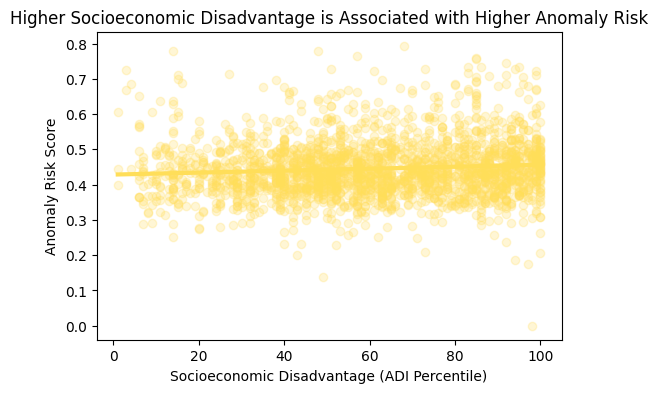

A 10-percentile increase in socioeconomic disadvantage is associated with a 0.003 increase in anomaly risk score.


In [1027]:
#Insight: Socioeconomic disadvantage significantly increases anomaly risk odds
# Chart: Logistic relationship between ADI percentile and probability of high anomaly risk.
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

# Linear regression
model = smf.ols(
    "risk_score ~ ADI_NATRANK_clean",
    data=final
).fit()

print(model.summary())

x_vals = np.linspace(
    final["ADI_NATRANK_clean"].min(),
    final["ADI_NATRANK_clean"].max(),
    100
)

pred_df = {"ADI_NATRANK_clean": x_vals}
pred = model.predict(pred_df)

plt.figure(figsize=(6,4), facecolor="white")

plt.scatter(
    final["ADI_NATRANK_clean"],
    final["risk_score"],
    alpha=0.25,
    color="#ffde59"
)

plt.plot(
    x_vals,
    pred,
    linewidth=3,
    color="#ffde59"
)

plt.xlabel("Socioeconomic Disadvantage (ADI Percentile)")
plt.ylabel("Anomaly Risk Score")
plt.title("Higher Socioeconomic Disadvantage is Associated with Higher Anomaly Risk")
plt.show()

coef = model.params["ADI_NATRANK_clean"]

ten_point_effect = coef * 10

print(
f"A 10-percentile increase in socioeconomic disadvantage is associated with "
f"a {ten_point_effect:.3f} increase in anomaly risk score."
)

# Delete

In [993]:
# =====================================================
# PRESENTATION VISUALS
# DataFrame: final
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1️⃣ Top 5 Highest Risk Facilities
# --------------------------------------------------

top5 = (
    final.sort_values("risk_score", ascending=False)
    .head(5)[[
        "site_name",
        "total_emissions",
        "primary_naics_description",
        #    "risk_percentile",
        #"ADI_NATRANK_clean",
       # "GEOID10"
    ]]
)

print("Top 5 Highest Risk Facilities")
display(top5)

Top 5 Highest Risk Facilities


,site_name,total_emissions,primary_naics_description
1436,IL Bell Telephone Co dba AT&T Illinois,0.363600,Agents for Wireless Telecommunications Services
1842,North Shore Water Reclamation Dist,1.705350,Sewage Treatment Facilities
600,Airgas USA LLC,0.003250,Other Chemical and Allied Products Merchant Wh...
2113,AkzoNobel Aerospace Coating,5.022252,Paint and Coating Manufacturing
311,Rehabilitation Institute of Chicago,5.944470,Specialty (except Psychiatric and Substance Ab...


In [994]:
# --------------------------------------------------
# 2️⃣ Anomaly Findings
# --------------------------------------------------

RISK_THRESHOLD = final["risk_score"].quantile(0.90)

high_risk = final[final["risk_score"] > RISK_THRESHOLD]
high_risk_count = len(high_risk)

print("\nAnomaly Findings")
print("Risk Threshold (90th percentile):", round(RISK_THRESHOLD, 4))
print("Number of High-Risk Facilities:", high_risk_count)


Anomaly Findings
Risk Threshold (90th percentile): 0.5522
Number of High-Risk Facilities: 229


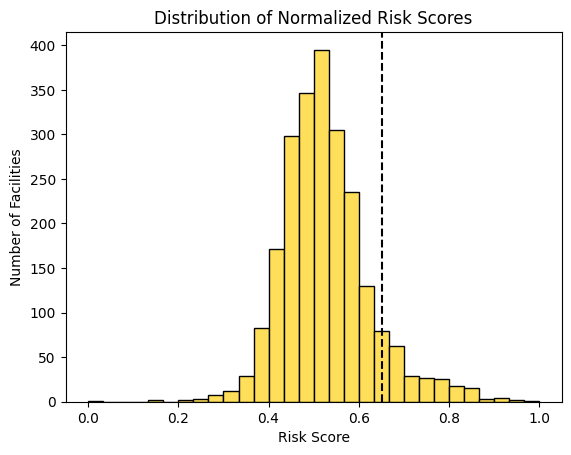

In [995]:
# --------------------------------------------------
# 3️⃣ Risk Score Distribution
# --------------------------------------------------
RISK_THRESHOLD = final["risk_norm"].quantile(0.90)
plt.figure()
plt.hist(final["risk_norm"], bins=30, color="#ffde59", edgecolor="black")
plt.axvline(RISK_THRESHOLD, color="black", linestyle="--")
plt.title("Distribution of Normalized Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Facilities")
plt.gca().set_facecolor("white")
plt.show()

In [996]:
# --------------------------------------------------
# Socioeconomic Findings – GEOID Summary
# --------------------------------------------------

geo_summary = (
    high_risk
    .groupby("GEOID10")
    .agg(
        facility_count=("facility_id", "count"),
        avg_ADI=("ADI_NATRANK_clean", "mean"),
        max_risk=("risk_score", "max"),
        dominant_socio_risk=(
            "socioeconomic_risk_level",
            lambda x: x.mode().iloc[0] if not x.mode().empty else None
        )
    )
    .sort_values("max_risk", ascending=False)
)

print("\nCensus GEOIDs with Highest Risk Facilities")
display(geo_summary.head(10))


Census GEOIDs with Highest Risk Facilities


,facility_count,avg_ADI,max_risk,dominant_socio_risk
GEOID10,,,,
1.709786e+11,4,NaN,0.847930,None
1.703153e+11,1,68.0,0.793765,High
1.703108e+11,2,14.0,0.779511,Low
1.703131e+11,1,48.0,0.778062,High
1.709786e+11,1,57.0,0.763908,High
1.711940e+11,3,85.0,0.760000,High
1.703184e+11,9,85.0,0.756688,High
1.703151e+11,2,92.0,0.744662,High
1.702196e+11,1,86.0,0.734724,High


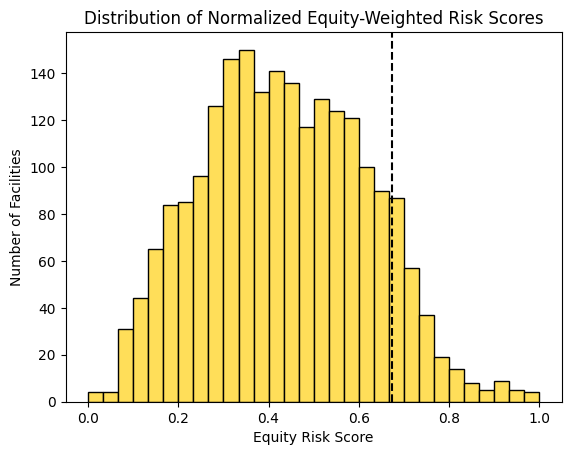

In [998]:
# --------------------------------------------------
# Socioeconomic Risk Score Distribution
# --------------------------------------------------
RISK_THRESHOLD = final["equity_weighted_risk_norm"].quantile(0.90)
plt.figure()
plt.hist(final["equity_weighted_risk_norm"], bins=30, color="#ffde59", edgecolor="black")
plt.axvline(RISK_THRESHOLD, color="black", linestyle="--")
plt.title("Distribution of Normalized Equity-Weighted Risk Scores")
plt.xlabel("Equity Risk Score")
plt.ylabel("Number of Facilities")
plt.gca().set_facecolor("white")
plt.show()

In [1001]:
print(df["size_adjusted_residual"].describe())

print("\nMean residual for high risk:")
print(df.groupby("high_risk_flag")["size_adjusted_residual"].mean())

count    2.287000e+03
mean     1.724317e-16
std      4.113193e-01
min     -1.686475e+00
25%     -2.582347e-01
50%     -4.493083e-02
75%      1.950086e-01
max      2.681537e+00
Name: size_adjusted_residual, dtype: float64

Mean residual for high risk:
high_risk_flag
0   -0.065125
1    0.585271
Name: size_adjusted_residual, dtype: float64


In [1005]:
# ============================================
# Do Larger Emitters Have Higher Anomaly Risk?
# ============================================

import numpy as np
import statsmodels.api as sm

# 1️⃣ Define high anomaly risk (top 10%)
risk_threshold = final["risk_norm"].quantile(0.90)
final["high_risk_flag"] = (final["risk_norm"] > risk_threshold).astype(int)

# 2️⃣ Define top emitters (top 10% reported emissions)
emission_threshold = final["total_emissions"].quantile(0.90)
final["top_emitter_flag"] = (final["total_emissions"] > emission_threshold).astype(int)

# 3️⃣ Logistic regression:
#    Outcome = high anomaly risk
#    Predictor = top emitter
X = sm.add_constant(final["top_emitter_flag"])
y = final["high_risk_flag"]

model = sm.Logit(y, X).fit(disp=False)

# 4️⃣ Convert to odds ratio
odds_ratio = np.exp(model.params["top_emitter_flag"])
p_value = model.pvalues["top_emitter_flag"]

# 5️⃣ Output clean interpretation
print("==========================================")
print("Anomaly Risk vs Facility Emission Size")
print("==========================================")
print(f"Odds Ratio: {odds_ratio:.2f}")
print(f"P-value: {p_value:.4f}")
print()

if odds_ratio > 1:
    print(
        f"Facilities in the top 10% of reported emissions "
        f"have {odds_ratio:.2f} times higher odds "
        f"of being classified as high anomaly risk."
    )
else:
    print(
        f"Top-emitting facilities have {(1-odds_ratio)*100:.1f}% "
        f"lower odds of being high anomaly risk."
    )

Anomaly Risk vs Facility Emission Size
Odds Ratio: 1.23
P-value: 0.3457

Facilities in the top 10% of reported emissions have 1.23 times higher odds of being classified as high anomaly risk.


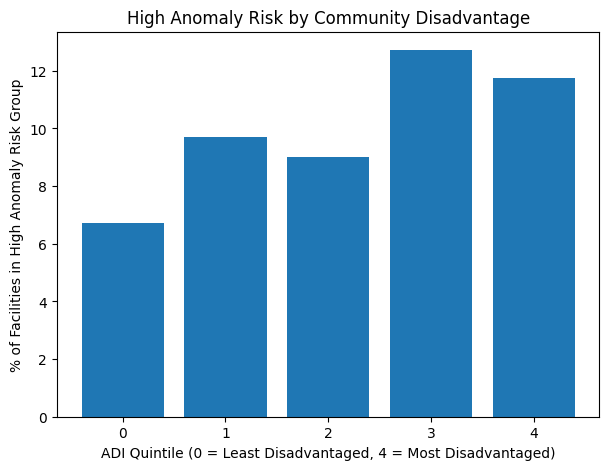

   adi_quintile  high_anomaly  percent_high_risk
0           0.0      0.067365           6.736527
1           1.0      0.097015           9.701493
2           2.0      0.090110           9.010989
3           3.0      0.127193          12.719298
4           4.0      0.117647          11.764706


In [1017]:
# Chart: Anomaly Risk by Socioeconomic Disadvantage (ADI Quintile)
# Purpose: Show that higher-disadvantage communities have more high-risk facilities.
import pandas as pd
import matplotlib.pyplot as plt

# Define high anomaly risk (top 10%)
threshold = final["risk_score"].quantile(0.90)
final["high_anomaly"] = final["risk_score"] > threshold

# Percent high risk per ADI quintile
adi_summary = (
    final.groupby("adi_quintile")["high_anomaly"]
    .mean()
    .reset_index()
)

adi_summary["percent_high_risk"] = adi_summary["high_anomaly"] * 100

# Plot
plt.figure(figsize=(7,5))
plt.bar(adi_summary["adi_quintile"], adi_summary["percent_high_risk"])
plt.xlabel("ADI Quintile (0 = Least Disadvantaged, 4 = Most Disadvantaged)")
plt.ylabel("% of Facilities in High Anomaly Risk Group")
plt.title("High Anomaly Risk by Community Disadvantage")
plt.show()

# Key numbers for slide
print(adi_summary)

In [1021]:
ratio = (
    adi_summary.loc[adi_summary["adi_quintile"] == 4, "percent_high_risk"].values[0] /
    adi_summary.loc[adi_summary["adi_quintile"] == 0, "percent_high_risk"].values[0]
)

print("Risk ratio (Q4 vs Q0):", ratio)
#"Facilities in the most disadvantaged communities are ~X× more likely to be flagged high risk."

Risk ratio (Q4 vs Q0): 1.7464052287581697


In [1022]:
# Chart: Logistic Relationship Between ADI and Anomaly Risk
import statsmodels.formula.api as smf
import numpy as np

# Logistic regression
model = smf.logit(
    "high_anomaly ~ ADI_NATRANK_clean",
    data=final
).fit()

print(model.summary())

# Odds ratio
odds_ratio = np.exp(model.params["ADI_NATRANK_clean"])
print("Odds ratio per percentile:", odds_ratio)

# Predict curve
x_vals = np.linspace(
    final["ADI_NATRANK_clean"].min(),
    final["ADI_NATRANK_clean"].max(),
    100
)

pred_df = pd.DataFrame({"ADI_NATRANK_clean": x_vals})
pred_df["pred_prob"] = model.predict(pred_df)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(final["ADI_NATRANK_clean"], final["high_anomaly"], alpha=0.2)
plt.plot(x_vals, pred_df["pred_prob"], linewidth=3)

plt.xlabel("Socioeconomic Disadvantage (ADI Percentile)")
plt.ylabel("Probability of High Anomaly Risk")
plt.title("Higher Socioeconomic Disadvantage Increases Underreporting Risk")
plt.show()

ValueError: endog has evaluated to an array with multiple columns that has shape (2170, 2). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).